In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# 1. Capa de Extracción (E)
url_base = "https://api.coingecko.com/api/v3/coins/markets"

# CoinGecko nos permite pedir múltiples monedas separadas por coma
parametros = {
    "vs_currency": "usd",
    "ids": "bitcoin,ethereum,solana,cardano,ripple", 
    "order": "market_cap_desc"
}

try:
    print("Conectando con los servidores de CoinGecko...")
    respuesta = requests.get(url_base, params=parametros, timeout=10)
    respuesta.raise_for_status()
    
    datos_cripto = respuesta.json()
    print("¡Datos de mercado obtenidos con éxito!\n")

except requests.exceptions.RequestException as e:
    print(f"Error crítico en el pipeline: {e}")

Conectando con los servidores de CoinGecko...
¡Datos de mercado obtenidos con éxito!



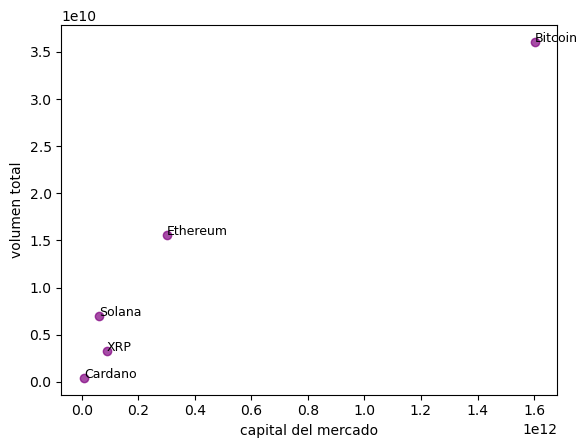

In [6]:
df_mercado = pd.DataFrame(datos_cripto)
df_mercado[['name', 'current_price', 'total_volume']]
plt.scatter(df_mercado['market_cap'], df_mercado['total_volume'], color='purple', alpha=0.7)
# Iteramos sobre cada fila del DataFrame para ponerle una etiqueta a su punto
for indice, fila in df_mercado.iterrows():
    # plt.text(coordenada_x, coordenada_y, texto_a_mostrar)
    plt.text(fila['market_cap'], fila['total_volume'], fila['name'], fontsize=9)
plt.xlabel('capital del mercado')
plt.ylabel('volumen total')
plt.show()